# EDA — Online Retail Dataset

Dataset: `data/raw/Online Retail.xlsx`

Separate exploratory analysis for PricePilot AI.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

FILE = ROOT / "data" / "raw" / "Online Retail.xlsx"
df = pd.read_excel(FILE, sheet_name=0)
print("Shape:", df.shape)
display(df.head())


Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print("Columns:", df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))
print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("missing"))
print("Duplicate rows:", df.duplicated().sum())


Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:


,dtype
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object



Missing values:


,missing
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0


Duplicate rows: 5268


In [4]:
display(df[["Quantity", "UnitPrice"]].describe())
print("Unique products:", df["StockCode"].nunique())
print("Unique customers:", df["CustomerID"].nunique())
print("Unique countries:", df["Country"].nunique())


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


Unique products: 4070
Unique customers: 4372
Unique countries: 38


In [5]:
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
print("Cancelled invoices:", df["InvoiceNo"].str.startswith("C").sum())
print("Negative quantity:", (df["Quantity"] < 0).sum())
print("Non-positive price:", (df["UnitPrice"] <= 0).sum())
print("Date range:", df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())


Cancelled invoices: 9288
Negative quantity: 10624
Non-positive price: 2517
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [6]:
clean = df[
    (~df["InvoiceNo"].str.startswith("C")) &
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0) &
    df["InvoiceDate"].notna()
].copy()
clean["Revenue"] = clean["Quantity"] * clean["UnitPrice"]

print("Rows before:", len(df))
print("Rows after cleaning:", len(clean))
print("Total units:", clean["Quantity"].sum())
print("Total revenue:", clean["Revenue"].sum())


Rows before: 541909
Rows after cleaning: 530104
Total units: 5588376
Total revenue: 10666684.544


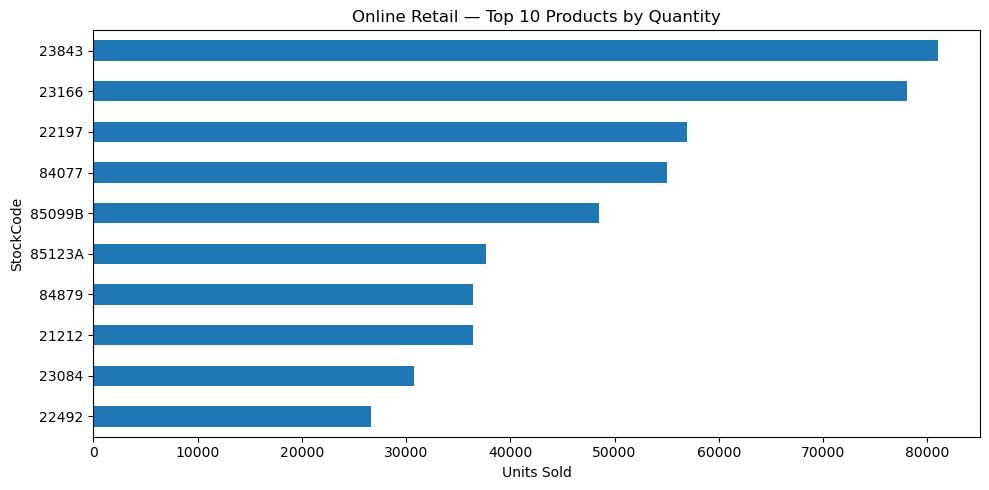

In [7]:
top = clean.groupby("StockCode")["Quantity"].sum().nlargest(10).sort_values()
plt.figure(figsize=(10,5))
top.plot(kind="barh")
plt.title("Online Retail — Top 10 Products by Quantity")
plt.xlabel("Units Sold")
plt.tight_layout()
plt.show()


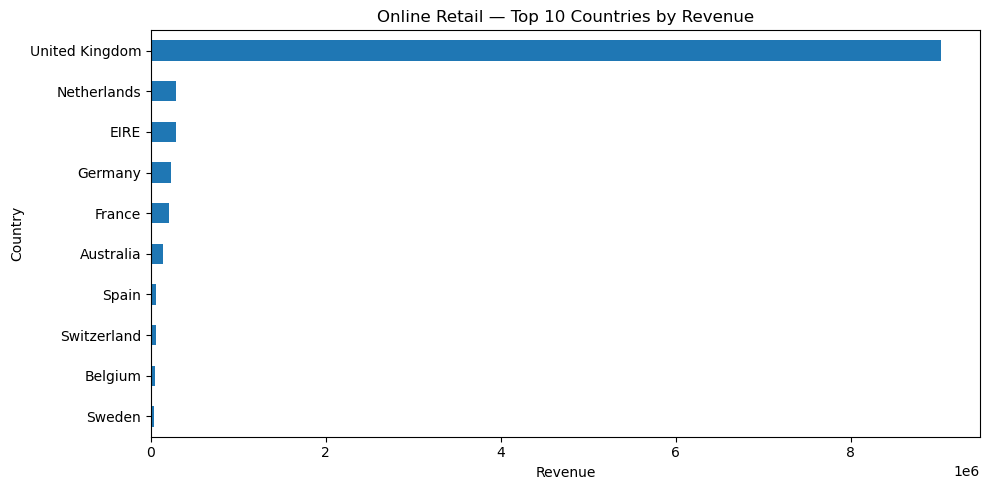

In [8]:
country = clean.groupby("Country")["Revenue"].sum().nlargest(10).sort_values()
plt.figure(figsize=(10,5))
country.plot(kind="barh")
plt.title("Online Retail — Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()


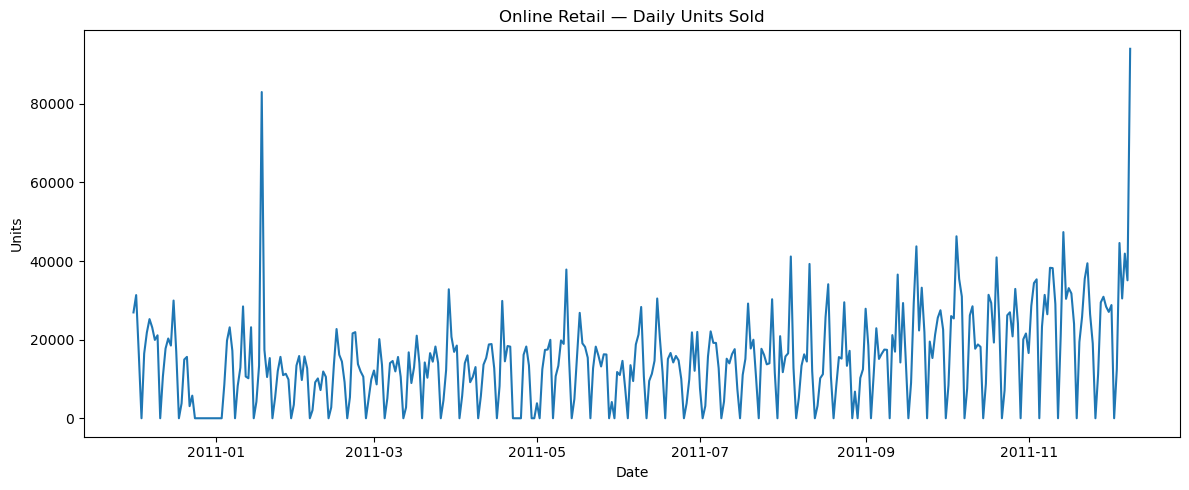

In [9]:
daily = clean.set_index("InvoiceDate").resample("D").agg(
    Units=("Quantity","sum"), Revenue=("Revenue","sum")
)
plt.figure(figsize=(12,5))
plt.plot(daily.index, daily["Units"])
plt.title("Online Retail — Daily Units Sold")
plt.xlabel("Date")
plt.ylabel("Units")
plt.tight_layout()
plt.show()


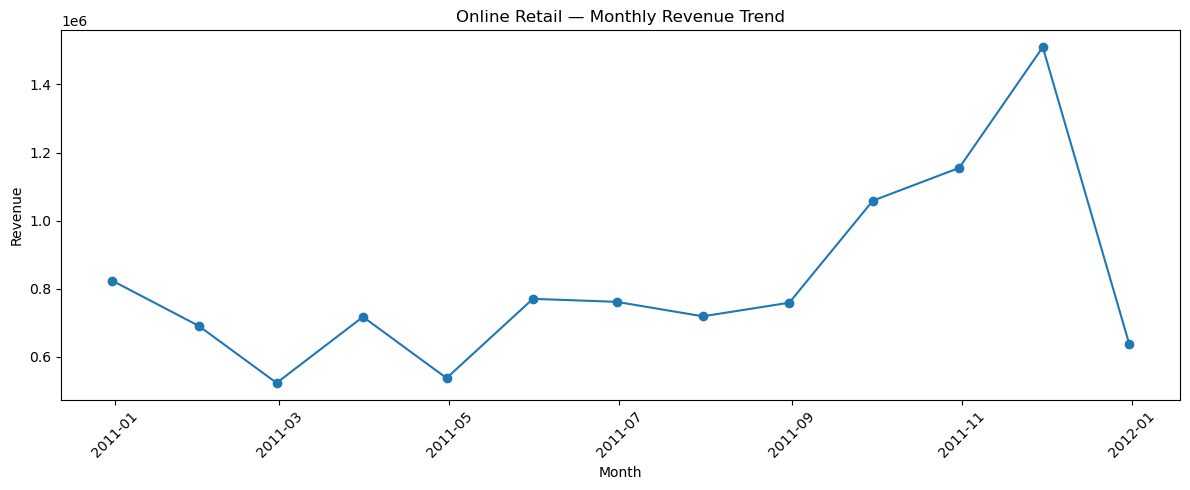

In [10]:
monthly = clean.set_index("InvoiceDate").resample("ME")["Revenue"].sum()
plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Online Retail — Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


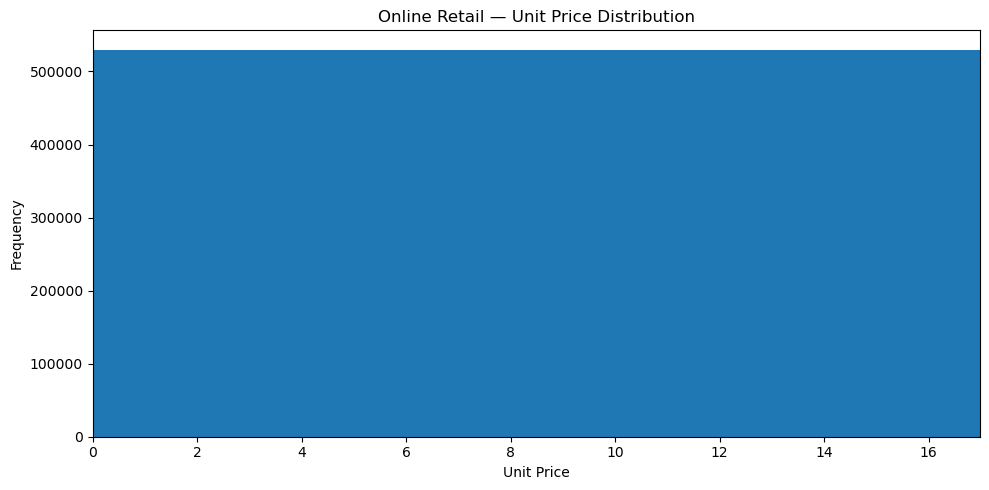

In [11]:
plt.figure(figsize=(10,5))
plt.hist(clean["UnitPrice"], bins=50)
plt.title("Online Retail — Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.xlim(0, clean["UnitPrice"].quantile(.99))
plt.tight_layout()
plt.show()


In [12]:
print("Correlation matrix:")
display(clean[["Quantity","UnitPrice","Revenue"]].corr())


Correlation matrix:


,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.003773,0.907338
UnitPrice,-0.003773,1.000000,0.137404
Revenue,0.907338,0.137404,1.000000


## Conclusion

The cleaned Online Retail data provides historical product demand, price, revenue and date information suitable for product-day demand forecasting and pricing analysis.